In this notebook, we consider the results for the squared exponential correlation function.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
from scipy.special import kv, gamma
import scipy.linalg
import gaussian_crossings as gc

In [ ]:
# For a squared-exponential process
def r_squared_exponential(t, sigma, tau):
    """
    Squared exponential autocovariance function.
    
    Parameters:
        t : tensor or array
            Time differences.
        sigma : float
            Standard deviation (amplitude) of the process.
        tau : float
            Exponential decay time constant.
    
    Returns:
        Tensor: The autocovariance computed at times t.
    """
    return sigma ** 2 * (torch.exp(- (t / (2 * tau)) ** 2))

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
sigma = 1.0 # Standard deviation (amplitude) of the process

In [9]:
num_points_taus = 100
taus = torch.linspace(0.01, 1.0, num_points_taus)

num_points_zeta = 100
zeta = torch.linspace(0.0, sigma * 5.0, num_points_zeta) / sigma

mean_rates = torch.zeros(num_points_taus, num_points_zeta)
fano_factors = torch.zeros(num_points_taus, num_points_zeta)

In [10]:
for i in range(num_points_taus):
    for j in range(num_points_zeta):
        u = zeta[j] * sigma
        tau = taus[i]
        model = gc.GaussianUpCrossings(r_func=r_squared_exponential, u=u, tau=tau, sigma=sigma)
        mean_rates[i, j] = model.upcrossing_mean_rate()
        fano_factors[i, j] = model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5)

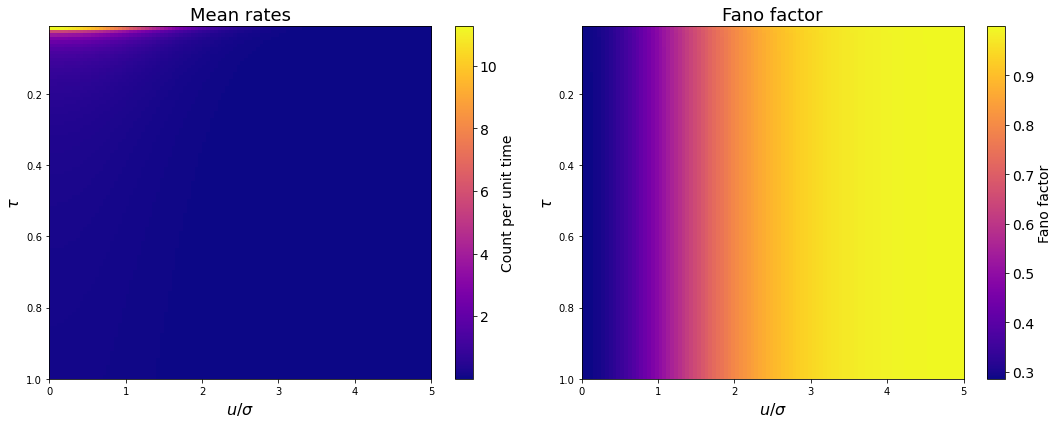

In [11]:
cmap = 'plasma'
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 18
cbar_labelsize = 14

# Number of ticks to display on each axis
num_ticks = 5

# Create a figure with two subplots (left and right)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------------------
# Left subplot: mean_rates
# -------------------
im0 = axes[0].imshow(mean_rates,
                     extent=[zeta[0], zeta[-1], taus[-1], taus[0]],
                     aspect='auto',
                     cmap=cmap)

# Add a colorbar with a label
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label("Count per unit time", fontsize=cbar_labelsize)
cbar0.ax.tick_params(labelsize=tick_fontsize)

# Set the axis labels and title with larger fonts
axes[0].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[0].set_ylabel(r'$\tau$', fontsize=label_fontsize)
axes[0].set_title('Mean rates', fontsize=title_fontsize)

# -------------------
# Right subplot: fano_factors
# -------------------
im1 = axes[1].imshow(fano_factors,
                     extent=[zeta[0], zeta[-1], taus[-1], taus[0]],
                     aspect='auto',
                     cmap=cmap)

# Add a colorbar with a label
cbar1 = fig.colorbar(im1, ax=axes[1])
cbar1.set_label("Fano factor", fontsize=cbar_labelsize)
cbar1.ax.tick_params(labelsize=tick_fontsize)

# Set the axis labels and title with larger fonts
axes[1].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[1].set_ylabel(r'$\tau$', fontsize=label_fontsize)
axes[1].set_title('Fano factor', fontsize=title_fontsize)

# Improve layout spacing
plt.tight_layout()
plt.show()

In [15]:
model = gc.GaussianUpCrossings(r_func=r_squared_exponential, u=0.0, tau=1.0, sigma=sigma)
print(model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5))

tensor([0.2859])
